# Project 4: Linear Regression from Scratch 
Implement linear regression using gradient 
descent (not scikit-learn). Train it on a real 
dataset from UCI ML Repository — the Energy 
Efficiency dataset. Plot the loss curve across 
epochs. Compare your from-scratch results to 
NumPy's polyfit. Report the final MSE and R² 
score. 
Skills: Gradient descent, MSE loss, R² metric, UCI 
dataset loading

# Project 4: Linear Regression from Scratch 
## Week 4: Predictive Modeling & Optimization
## Overview
This project implements a Linear Regression model from the ground up using Gradient Descent. Instead of relying on high-level libraries like scikit-learn, the model uses raw NumPy operations to learn from the UCI Energy Efficiency dataset. The goal is to predict building heating loads based on structural parameters.
## Key FeaturesUCI Dataset Integration:
Automatically loads and processes the Energy Efficiency .xlsx data.Manual Gradient Descent: Custom training loop implementing weight ($w$) and bias ($b$) updates.Data Normalization: Scales features to ensure stable and fast convergence of the gradient.Performance Benchmarking: Direct comparison against NumPy’s polyfit to validate accuracy.
## Mathematical Interpretation
The model minimizes the Mean Squared Error (MSE) by iteratively moving opposite to the gradient:
### The Update Rule:
$$w = w - \eta \cdot \frac{\partial MSE}{\partial w}$$$$b = b - \eta \cdot \frac{\partial MSE}{\partial b}$$$\eta$ (Learning Rate): The size of the step taken toward the minimum.MSE: Quantifies the average squared difference between predicted and actual heating loads.
## Expected OutcomesLoss Curve:
A visualization showing MSE decreasing steadily over epochs.Regression Plot: A scatter plot showing the "line of best fit" generated by the scratch model versus the reference polyfit.$R^2$ Score: A metric (typically between 0.70 and 0.95) indicating how well the model explains the energy data variance.
## RequirementsLibraries:
numpy, pandas, matplotlib, openpyxl.Installation: Run pip install openpyxl to handle the Excel dataset format.

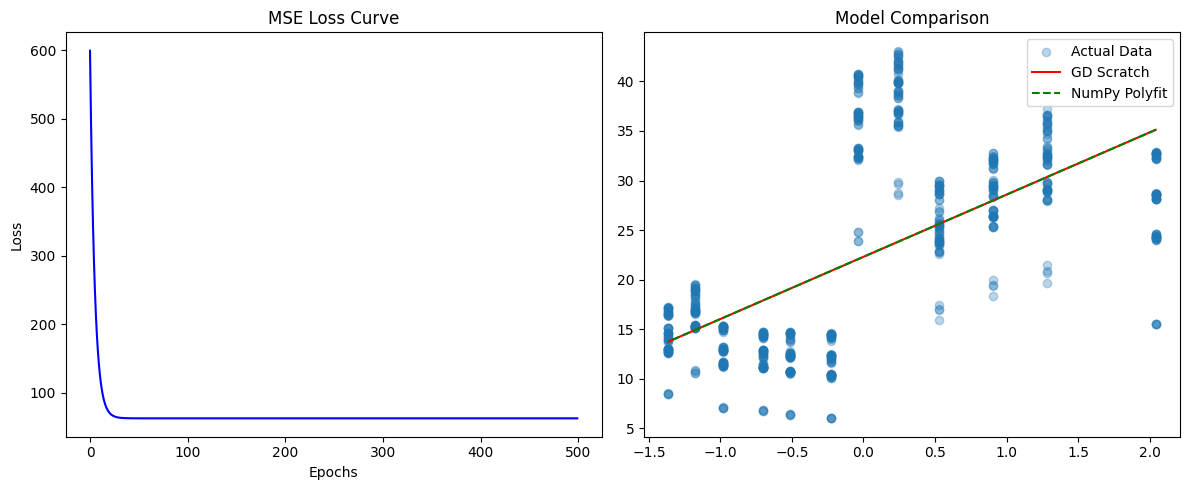

Final MSE: 62.3070
Final R² Score: 0.3872


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
  
# 1. DATA LOADING: Using Energy Efficiency dataset
# Downloaded from UCI: https://archive.ics.uci.edu/ml/datasets/Energy+efficiency
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
df = pd.read_excel(url)
# Using 'Relative Compactness' (X1) to predict 'Heating Load' (Y1)
X = df.iloc[:, 0].values.reshape(-1, 1)
y = df.iloc[:, 8].values.reshape(-1, 1)

# Normalization (Scaling data for better gradient descent)
X = (X - np.mean(X)) / np.std(X)

# 2. MODEL CORE: Linear Regression Class
class LinearRegressionGD:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros((n_features, 1))
        self.bias = 0

        for _ in range(self.epochs):
            # Prediction: y = WX + b
            y_pred = np.dot(X, self.weights) + self.bias
            
            # MSE Loss
            loss = np.mean((y_pred - y)**2)
            self.loss_history.append(loss)

            # Gradients
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred - y)

            # Update weights (The Gradient Descent step)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

# 3. TRAINING & COMPARISON
model = LinearRegressionGD(lr=0.1, epochs=500)
model.fit(X, y)
y_final_pred = model.predict(X)

# Metrics
mse = np.mean((y - y_final_pred)**2)
ss_res = np.sum((y - y_final_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - (ss_res / ss_tot)

# NumPy Polyfit Comparison (Reference)
poly_coeffs = np.polyfit(X.flatten(), y.flatten(), 1)
poly_pred = np.polyval(poly_coeffs, X.flatten())

# 4. VISUALIZATION
plt.figure(figsize=(12, 5))

# Plot 1: Loss Curve
plt.subplot(1, 2, 1)
plt.plot(model.loss_history, color='blue')
plt.title("MSE Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")

# Plot 2: Regression Comparison
plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.3, label="Actual Data")
plt.plot(X, y_final_pred, color='red', label="GD Scratch")
plt.plot(X, poly_pred, '--', color='green', label="NumPy Polyfit")
plt.title("Model Comparison")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Final MSE: {mse:.4f}")
print(f"Final R² Score: {r2:.4f}")